In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys
sys.path.append("/n/home12/binxuwang/Github/DiffusionAttnConsistency")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
import json
from tqdm import tqdm
from easydict import EasyDict as edict
from core.parity_lib import parity_func, round_to_pos_neg_one
from circuit_toolkit import saveallforms

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


In [3]:
def get_all_available_steps(sample_dir, excluded_steps=[]):
    """Get all available step numbers from sample files in the directory."""
    sample_files = [f for f in os.listdir(sample_dir) if f.startswith("samples_epoch_") and f.endswith(".pt")]
    steps = []
    for f in sample_files:
        step_str = f.replace("samples_epoch_", "").replace(".pt", "")
        steps.append(int(step_str))
    steps = sorted(steps)
    steps = [step for step in steps if step not in excluded_steps]
    return steps

# Get available steps
# steps = get_all_available_steps(sample_dir)
# print(f"Available steps: {steps}")

In [25]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
exp_name = 'DiT_S_parity_N4096_D36_G9_even'
savedir = f"{saveroot}/{exp_name}"
sample_dir = f"{savedir}/samples"
ckpt_dir = f"{savedir}/ckpts"
args = edict(json.load(open(f"{savedir}/args.json")))
config = json.load(open(f"{savedir}/config.json"))
train_sample_num = args.sample_num
sample_len = args.sample_len
group_size = args.group_size
parity = args.parity
Xtsr = th.load(f"{savedir}/training_data_tsr.pt", weights_only=False)
num_groups = sample_len // group_size
nlayer = config["depth"]
nhead  = config["num_heads"]
all_steps = get_all_available_steps(sample_dir, excluded_steps=[])
# pbar = tqdm(all_steps)
# for step in pbar:
step = all_steps[-10]
sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt", weights_only=False)
eval_sample_num = sample_tsr.shape[0]
eps = 1e-2
sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
nan_num_eps_1e_2 = th.sum(th.isnan(exist_nan)).item()
nan_ratio_eps_1e_2 = nan_num_eps_1e_2 / eval_sample_num

eps = 1e-1
sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
nan_num_eps_1e_1 = th.sum(th.isnan(exist_nan)).item()
nan_ratio_eps_1e_1 = nan_num_eps_1e_1 / eval_sample_num

In [39]:
train_sample_set = {tuple(sample.tolist()) for sample in Xtsr.to(int).flatten(start_dim=1)}
train_bitgroup_mat = Xtsr.to(int).flatten(start_dim=1).view(-1, group_size)
train_bitgroup_set = {tuple(row.tolist()) for row in train_bitgroup_mat}
print(f"Unique training samples: {len(train_sample_set)}")
print(f"Unique training bitgroups: {len(train_bitgroup_set)} | all combo N={2**group_size} | correct parity combo N={2**(group_size-1)}")

Unique training samples: 4096
Unique training bitgroups: 256 | all combo N=512 | correct parity combo N=256


In [46]:
step = all_steps[1200]
sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt", weights_only=False)
eps = 1e-1
sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
gen_samples_mat = sample_tsr_int.to(int).flatten(start_dim=1)
num_in_train_set = 0
num_train_set = len(train_sample_set)
num_gen_samples = gen_samples_mat.shape[0]
for i in range(gen_samples_mat.shape[0]):
    sample_tuple = tuple(gen_samples_mat[i].tolist())
    if sample_tuple in train_sample_set:
        num_in_train_set += 1
    
print(f"num_in_train_set: {num_in_train_set}, num_train_set: {num_train_set}, num_gen_samples: {num_gen_samples}")
print(f"num_in_train_set / num_gen_samples: {num_in_train_set / num_gen_samples}")

num_row_in_train_set = 0
num_row_train_set = len(train_bitgroup_set)
gen_row_mat = gen_samples_mat.view(-1, group_size)
num_row_gen_samples = gen_row_mat.shape[0]
for i in range(gen_row_mat.shape[0]):
    sample_tuple = tuple(gen_row_mat[i].tolist())
    if sample_tuple in train_bitgroup_set:
        num_row_in_train_set += 1
    
print(f"num_in_train_set: {num_row_in_train_set}, num_train_set: {len(train_bitgroup_set)}, num_gen_rows: {num_row_gen_samples}")
print(f"num_in_train_set / num_gen_samples: {num_row_in_train_set / num_row_gen_samples}")

num_in_train_set: 1086, num_train_set: 4096, num_gen_samples: 2048
num_in_train_set / num_gen_samples: 0.5302734375
num_in_train_set: 6612, num_train_set: 256, num_gen_rows: 8192
num_in_train_set / num_gen_samples: 0.80712890625


In [ ]:
train_sample_set = {tuple(sample.tolist()) for sample in Xtsr.to(int).flatten(start_dim=1)}
train_bitgroup_mat = Xtsr.to(int).flatten(start_dim=1).view(-1, group_size)
train_bitgroup_set = {tuple(row.tolist()) for row in train_bitgroup_mat}
print(f"Unique training samples: {len(train_sample_set)}")
print(f"Unique training bitgroups: {len(train_bitgroup_set)} | all combo N={2**group_size} | correct parity combo N={2**(group_size-1)}")

Unique training samples: 4096
Unique training bitgroups: 256 | all combo N=512 | correct parity combo N=256


In [48]:
mem_stats = []
pbar = tqdm(all_steps)
for step in pbar:
    sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt", weights_only=False)
    eps = 1e-1
    sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
    gen_samples_mat = sample_tsr_int.to(int).flatten(start_dim=1)
    num_sample_in_train_set = 0
    num_train_set = len(train_sample_set)
    num_gen_samples = gen_samples_mat.shape[0]
    for i in range(gen_samples_mat.shape[0]):
        sample_tuple = tuple(gen_samples_mat[i].tolist())
        if sample_tuple in train_sample_set:
            num_sample_in_train_set += 1
        
    # print(f"num_in_train_set: {num_sample_in_train_set}, num_train_set: {num_train_set}, num_gen_samples: {num_gen_samples}")
    # print(f"num_in_train_set / num_gen_samples: {num_sample_in_train_set / num_gen_samples}")

    num_row_in_train_set = 0
    num_row_train_set = len(train_bitgroup_set)
    gen_row_mat = gen_samples_mat.view(-1, group_size)
    num_row_gen_samples = gen_row_mat.shape[0]
    for i in range(gen_row_mat.shape[0]):
        sample_tuple = tuple(gen_row_mat[i].tolist())
        if sample_tuple in train_bitgroup_set:
            num_row_in_train_set += 1
    # print(f"num_in_train_set: {num_row_in_train_set}, num_train_set: {len(train_bitgroup_set)}, num_gen_rows: {num_row_gen_samples}")
    # print(f"num_in_train_set / num_gen_samples: {num_row_in_train_set / num_row_gen_samples}")
    pbar.set_description(f"step: {step}, sample_mem_num {num_sample_in_train_set} sample_mem_ratio: {num_sample_in_train_set / num_gen_samples}, bitgroup_mem_num {num_row_in_train_set} bitgroup_mem_ratio: {num_row_in_train_set / num_row_gen_samples}")
    mem_stats.append({
        "step": step,
        "sample_mem_num": num_sample_in_train_set,
        "sample_mem_ratio": num_sample_in_train_set / num_gen_samples,
        "bitgroup_mem_num": num_row_in_train_set,
        "bitgroup_mem_ratio": num_row_in_train_set / num_row_gen_samples,
    })
    
mem_stats_df = pd.DataFrame(mem_stats)

step: 1000000, sample_mem_num 1361 sample_mem_ratio: 0.66455078125, bitgroup_mem_num 7119 bitgroup_mem_ratio: 0.8690185546875: 100%|██████████| 1472/1472 [03:59<00:00,  6.14it/s]


In [49]:
import torch

def compute_membership_counts(train_int: torch.Tensor,
                              gen_int:   torch.Tensor,
                              group_size: int):
    """
    Args:
        train_int:    Tensor of shape [N_train, D], values in {−1, +1}
        gen_int:      Tensor of shape [N_gen, D], values in {−1, +1}
        group_size:   int, width of each bit‐group (must divide D)

    Returns a dict with:
        sample_mem_num    – how many full samples appear in the train set
        sample_mem_ratio  – sample_mem_num / N_gen
        bitgroup_mem_num  – how many bit‐groups appear in the train set
        bitgroup_mem_ratio– bitgroup_mem_num / (N_gen * D / group_size)
    """
    # ---- full‐sample codes ----
    N_gen, D = gen_int.shape

    # map −1→0, +1→1
    train_bits = (train_int > 0).long()  # [N_train, D]
    gen_bits   = (gen_int   > 0).long()  # [N_gen,   D]

    # build powers‐of‐two vector [1,2,4,…,2^(D−1)]
    weights = 1 << torch.arange(D, device=train_int.device, dtype=torch.long)

    # pack each row into a single integer code
    train_codes = (train_bits * weights).sum(dim=1).unique()
    gen_codes   = (gen_bits   * weights).sum(dim=1)

    # vectorized membership test
    mask = torch.isin(gen_codes, train_codes)
    sample_mem_num   = int(mask.sum().item())
    sample_mem_ratio = sample_mem_num / N_gen

    # ---- bit‐group codes ----
    # reshape into rows of width `group_size`
    BG_train = train_bits.view(-1, group_size)  # [N_train * (D/group_size), group_size]
    BG_gen   = gen_bits.view(-1,   group_size)  # [N_gen   * (D/group_size), group_size]

    # powers‐of‐two for each group
    gw = 1 << torch.arange(group_size, device=train_int.device, dtype=torch.long)

    train_group_codes = (BG_train * gw).sum(dim=1).unique()
    gen_group_codes   = (BG_gen   * gw).sum(dim=1)

    mask2 = torch.isin(gen_group_codes, train_group_codes)
    bitgroup_mem_num   = int(mask2.sum().item())
    bitgroup_mem_ratio = bitgroup_mem_num / gen_group_codes.numel()

    return {
        "sample_mem_num":    sample_mem_num,
        "sample_mem_ratio":  sample_mem_ratio,
        "bitgroup_mem_num":  bitgroup_mem_num,
        "bitgroup_mem_ratio": bitgroup_mem_ratio,
    }

In [54]:
compute_membership_counts(Xtsr.flatten(start_dim=1).cuda(), gen_samples_mat.cuda(), group_size)

{'sample_mem_num': 1362,
 'sample_mem_ratio': 0.6650390625,
 'bitgroup_mem_num': 7123,
 'bitgroup_mem_ratio': 0.8695068359375}

In [56]:
mem_stats = []
pbar = tqdm(all_steps)
for step in pbar:
    sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt", weights_only=False)
    eps = 1e-1
    sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
    gen_samples_mat = sample_tsr_int.to(int).flatten(start_dim=1)
    sample_mem_stats = compute_membership_counts(Xtsr.flatten(start_dim=1).cpu(), gen_samples_mat.cpu(), group_size)
    mem_stats.append({
        "step": step,
        **sample_mem_stats,
    })
    pbar.set_description(f"step: {step}, sample_mem_num {sample_mem_stats['sample_mem_num']} sample_mem_ratio: {sample_mem_stats['sample_mem_ratio']}, bitgroup_mem_num {sample_mem_stats['bitgroup_mem_num']} bitgroup_mem_ratio: {sample_mem_stats['bitgroup_mem_ratio']}")
    
mem_stats_df = pd.DataFrame(mem_stats)
# mem_stats_df.to_csv(f"{savedir}/mem_stats.csv", index=False)

  0%|          | 0/1472 [00:00<?, ?it/s]

step: 1000000, sample_mem_num 1362 sample_mem_ratio: 0.6650390625, bitgroup_mem_num 7123 bitgroup_mem_ratio: 0.8695068359375: 100%|██████████| 1472/1472 [00:06<00:00, 236.14it/s]


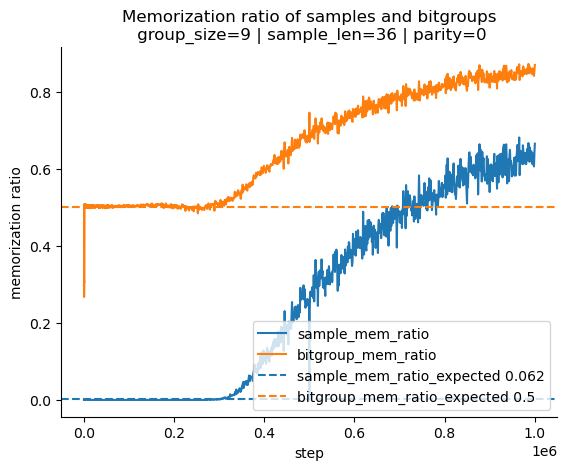

In [63]:
sns.lineplot(x="step", y="sample_mem_ratio", data=mem_stats_df, label='sample_mem_ratio')
sns.lineplot(x="step", y="bitgroup_mem_ratio", data=mem_stats_df, label='bitgroup_mem_ratio')
plt.axhline(y=0.5**group_size, color='C0', linestyle='--', label=f'sample_mem_ratio_expected {1/2**(sample_len // group_size):.3f}')
plt.axhline(y=0.5, color='C1', linestyle='--', label=f'bitgroup_mem_ratio_expected {1/2}')
plt.xlabel('step')
plt.ylabel('memorization ratio')
plt.title(f'Memorization ratio of samples and bitgroups\n group_size={group_size} | sample_len={sample_len} | parity={parity}')
plt.legend()
plt.show()

In [ ]:
synopsis_dir = f"/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures"
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
mem_eval_stats_df_all = []
for exp_name in [
                #
                'DiT_nano_parity_N4096_D36_G2_even',
                'DiT_nano_parity_N4096_D36_G3_even',
                'DiT_nano_parity_N4096_D36_G4_even',
                'DiT_nano_parity_N4096_D36_G6_even',
                'DiT_nano_parity_N4096_D36_G9_even',
                'DiT_nano_parity_N4096_D36_G12_even',
                'DiT_nano_parity_N4096_D36_G18_even',
                'DiT_nano_parity_N4096_D36_G36_even',
                # 
                'DiT_mini_parity_N4096_D36_G2_even',
                'DiT_mini_parity_N4096_D36_G3_even',
                'DiT_mini_parity_N4096_D36_G4_even',
                'DiT_mini_parity_N4096_D36_G6_even',
                'DiT_mini_parity_N4096_D36_G9_even',
                'DiT_mini_parity_N4096_D36_G12_even',
                'DiT_mini_parity_N4096_D36_G18_even',
                'DiT_mini_parity_N4096_D36_G36_even',
                #
                'DiT_S_parity_N4096_D36_G2_even',
                'DiT_S_parity_N4096_D36_G3_even',
                'DiT_S_parity_N4096_D36_G4_even',
                'DiT_S_parity_N4096_D36_G6_even',
                'DiT_S_parity_N4096_D36_G9_even',
                'DiT_S_parity_N4096_D36_G12_even',
                'DiT_S_parity_N4096_D36_G18_even',
                'DiT_S_parity_N4096_D36_G36_even',
                # 
                'DiT_B_parity_N4096_D36_G2_even',
                'DiT_B_parity_N4096_D36_G3_even',
                'DiT_B_parity_N4096_D36_G4_even',
                'DiT_B_parity_N4096_D36_G6_even',
                'DiT_B_parity_N4096_D36_G9_even',
                'DiT_B_parity_N4096_D36_G12_even',
                'DiT_B_parity_N4096_D36_G18_even',
                'DiT_B_parity_N4096_D36_G36_even',
                #
                ]:
    
    savedir = f"{saveroot}/{exp_name}"
    sample_dir = f"{savedir}/samples"
    ckpt_dir = f"{savedir}/ckpts"
    args = edict(json.load(open(f"{savedir}/args.json")))
    config = json.load(open(f"{savedir}/config.json"))
    train_sample_num = args.sample_num
    sample_len = args.sample_len
    group_size = args.group_size
    parity = args.parity
    Xtsr = th.load(f"{savedir}/training_data_tsr.pt", weights_only=False)
    num_groups = sample_len // group_size
    nlayer = config["depth"]
    nhead  = config["num_heads"]
    mem_eval_stats = []
    all_steps = get_all_available_steps(sample_dir, excluded_steps=[])
    pbar = tqdm(all_steps)
    for step in pbar:
        sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt", weights_only=False)
        eval_sample_num = sample_tsr.shape[0]
        eps = 1e-2
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
        nan_num_eps_1e_2 = th.sum(th.isnan(exist_nan)).item()
        nan_ratio_eps_1e_2 = nan_num_eps_1e_2 / eval_sample_num
        
        eps = 1e-1
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
        nan_num_eps_1e_1 = th.sum(th.isnan(exist_nan)).item()
        nan_ratio_eps_1e_1 = nan_num_eps_1e_1 / eval_sample_num
        # reshape to group as last dimension
        sample_pergroup_int = sample_tsr_int.reshape(eval_sample_num, num_groups, group_size)
        sample_eval_parity = parity_func(sample_pergroup_int, axis=-1)
        # count parity correctness for each group
        pergroup_parity_correctness = th.sum(sample_eval_parity == parity).sum()
        pergroup_parity_correctness_ratio = pergroup_parity_correctness / (eval_sample_num * num_groups)
        # count sample correct only when all groups are correct
        sample_correctness = th.all(sample_eval_parity == parity, dim=1).sum()
        sample_correctness_ratio = sample_correctness / eval_sample_num
        
        gen_samples_mat = sample_tsr_int.to(int).flatten(start_dim=1)
        sample_mem_stats = compute_membership_counts(Xtsr.flatten(start_dim=1).cpu(), gen_samples_mat.cpu(), group_size)
        mem_stats.append({
            "step": step,
            **sample_mem_stats,
        })
        pbar.set_description(f"step: {step}, sample_mem_num {sample_mem_stats['sample_mem_num']} sample_mem_ratio: {sample_mem_stats['sample_mem_ratio']:.3f}, bitgroup_mem_num {sample_mem_stats['bitgroup_mem_num']} bitgroup_mem_ratio: {sample_mem_stats['bitgroup_mem_ratio']:.3f}"+\
                    f"Bit group parity acc: {pergroup_parity_correctness_ratio:.3f}, Sample acc: {sample_correctness_ratio:.3f} nan: {nan_ratio_eps_1e_1:.3f}")
        
        mem_eval_stats.append({
            "step": step,
            **sample_mem_stats,
            "sample_num": eval_sample_num,
            "group_size": group_size,
            "nan_num_eps_1e-1": nan_num_eps_1e_1,
            "nan_ratio_eps_1e-1": nan_ratio_eps_1e_1,
            "nan_num_eps_1e-2": nan_num_eps_1e_2,
            "nan_ratio_eps_1e-2": nan_ratio_eps_1e_2,
            "pergroup_parity_num": pergroup_parity_correctness.item(),
            "pergroup_parity_acc": pergroup_parity_correctness_ratio.item(),
            "sample_corr_num": sample_correctness.item(),
            "sample_corr_acc": sample_correctness_ratio.item(),
        })
    # th.save(eval_stats, f"{savedir}/eval_stats.pt")
    mem_eval_stats_df = pd.DataFrame(mem_eval_stats)
    mem_eval_stats_df.to_csv(f"{savedir}/mem_eval_stats.csv", index=False)
    mem_eval_stats_df["exp_name"] = exp_name
    mem_eval_stats_df["group_size"] = group_size
    mem_eval_stats_df_all.append(mem_eval_stats_df)
    plt.figure(figsize=(6, 5))
    sns.lineplot(mem_eval_stats_df, x="step", y="pergroup_parity_acc",  label="Per group parity correctness", alpha=0.7) # hue="group_size",
    sns.lineplot(mem_eval_stats_df, x="step", y="sample_corr_acc",  label="Sample correctness", alpha=0.7) # hue="group_size",
    plt.axhline(y=0.5, linestyle=":", label="Per group accuracy baseline", color="C0", alpha=0.7)
    plt.axhline(y=0.5 ** num_groups, linestyle=":", label="Sample accuracy baseline", color="C1", alpha=0.7)
    sns.lineplot(mem_eval_stats_df, x="step", y="nan_ratio_eps_1e-1",  label="Exceed EPS ratio (eps=1e-1)", alpha=0.5, linestyle="--") # hue="group_size",
    sns.lineplot(mem_eval_stats_df, x="step", y="nan_ratio_eps_1e-2",  label="Exceed EPS ratio (eps=1e-2)", alpha=0.5, linestyle="--") # hue="group_size",
    sns.lineplot(mem_eval_stats_df, x="step", y="sample_mem_ratio",  label="Sample memorization ratio", alpha=0.7, linestyle=":", color="C5") # hue="group_size",
    sns.lineplot(mem_eval_stats_df, x="step", y="bitgroup_mem_ratio",  label="Bit group memorization ratio", alpha=0.7, linestyle=":", color="C6") # hue="group_size",
    plt.title(f"Sample evaluation \n {exp_name}\n DiT {nlayer}L{nhead}H {train_sample_num} samples, {sample_len} bits per sample, {group_size} bits per groups")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    saveallforms([synopsis_dir, savedir], f"{exp_name}_sample_parity_memorization_eval")
    plt.show()
    # raise Exception("Stop here")
mem_eval_stats_df_all = pd.concat(mem_eval_stats_df_all)
mem_eval_stats_df_all.to_csv(f"{saveroot}/mem_eval_stats_all_exps.csv", index=False)
mem_eval_stats_df_all.to_csv(f"{synopsis_dir}/mem_eval_stats_all_exps.csv", index=False)

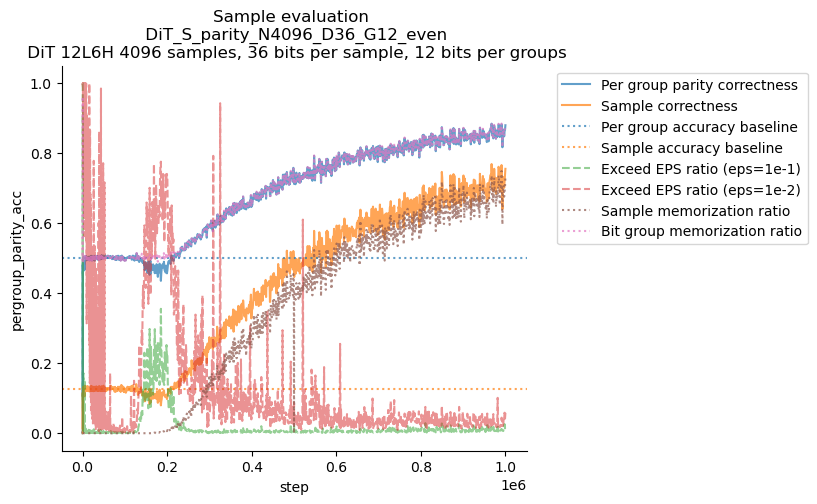

In [69]:
plt.figure(figsize=(6, 5))
sns.lineplot(mem_eval_stats_df, x="step", y="pergroup_parity_acc",  label="Per group parity correctness", alpha=0.7) # hue="group_size",
sns.lineplot(mem_eval_stats_df, x="step", y="sample_corr_acc",  label="Sample correctness", alpha=0.7) # hue="group_size",
plt.axhline(y=0.5, linestyle=":", label="Per group accuracy baseline", color="C0", alpha=0.7)
plt.axhline(y=0.5 ** num_groups, linestyle=":", label="Sample accuracy baseline", color="C1", alpha=0.7)
sns.lineplot(mem_eval_stats_df, x="step", y="nan_ratio_eps_1e-1",  label="Exceed EPS ratio (eps=1e-1)", alpha=0.5, linestyle="--") # hue="group_size",
sns.lineplot(mem_eval_stats_df, x="step", y="nan_ratio_eps_1e-2",  label="Exceed EPS ratio (eps=1e-2)", alpha=0.5, linestyle="--") # hue="group_size",
sns.lineplot(mem_eval_stats_df, x="step", y="sample_mem_ratio",  label="Sample memorization ratio", alpha=0.7, linestyle=":", color="C5") # hue="group_size",
sns.lineplot(mem_eval_stats_df, x="step", y="bitgroup_mem_ratio",  label="Bit group memorization ratio", alpha=0.7, linestyle=":", color="C6") # hue="group_size",
plt.title(f"Sample evaluation \n {exp_name}\n DiT {nlayer}L{nhead}H {train_sample_num} samples, {sample_len} bits per sample, {group_size} bits per groups")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
saveallforms([synopsis_dir, savedir], f"{exp_name}_sample_parity_memorization_eval")
plt.show()

In [ ]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
eval_stats_df_all = []
for exp_name in [
                #
                # 'DiT_B_parity_N4096_D36_G2_even',
                # 'DiT_B_parity_N4096_D36_G3_even',
                # 'DiT_B_parity_N4096_D36_G4_even',
                # 'DiT_B_parity_N4096_D36_G6_even',
                # 'DiT_B_parity_N4096_D36_G9_even',
                # 'DiT_B_parity_N4096_D36_G12_even',
                # 'DiT_B_parity_N4096_D36_G18_even',
                # 'DiT_B_parity_N4096_D36_G36_even',
                #
                'DiT_S_parity_N4096_D36_G2_even',
                'DiT_S_parity_N4096_D36_G3_even',
                'DiT_S_parity_N4096_D36_G4_even',
                'DiT_S_parity_N4096_D36_G6_even',
                'DiT_S_parity_N4096_D36_G9_even',
                'DiT_S_parity_N4096_D36_G12_even',
                'DiT_S_parity_N4096_D36_G18_even',
                'DiT_S_parity_N4096_D36_G36_even',
                #
                # 'DiT_nano_parity_N4096_D36_G2_even',
                # 'DiT_nano_parity_N4096_D36_G3_even',
                # 'DiT_nano_parity_N4096_D36_G4_even',
                # 'DiT_nano_parity_N4096_D36_G6_even',
                # 'DiT_nano_parity_N4096_D36_G9_even',
                # 'DiT_nano_parity_N4096_D36_G12_even',
                # 'DiT_nano_parity_N4096_D36_G18_even',
                # 'DiT_nano_parity_N4096_D36_G36_even',
                # # 
                # 'DiT_mini_parity_N4096_D36_G2_even',
                # 'DiT_mini_parity_N4096_D36_G3_even',
                # 'DiT_mini_parity_N4096_D36_G4_even',
                # 'DiT_mini_parity_N4096_D36_G6_even',
                # 'DiT_mini_parity_N4096_D36_G9_even',
                # 'DiT_mini_parity_N4096_D36_G12_even',
                # 'DiT_mini_parity_N4096_D36_G18_even',
                # 'DiT_mini_parity_N4096_D36_G36_even',
                ]:
    
    savedir = f"{saveroot}/{exp_name}"
    sample_dir = f"{savedir}/samples"
    ckpt_dir = f"{savedir}/ckpts"
    args = edict(json.load(open(f"{savedir}/args.json")))
    config = json.load(open(f"{savedir}/config.json"))
    train_sample_num = args.sample_num
    sample_len = args.sample_len
    group_size = args.group_size
    parity = args.parity
    Xtsr = th.load(f"{savedir}/training_data_tsr.pt", weights_only=False)
    num_groups = sample_len // group_size
    nlayer = config["depth"]
    nhead  = config["num_heads"]
    eval_stats = []
    all_steps = get_all_available_steps(sample_dir, excluded_steps=[])
    pbar = tqdm(all_steps)
    for step in pbar:
        sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt", weights_only=False)
        eval_sample_num = sample_tsr.shape[0]
        eps = 1e-2
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
        nan_num_eps_1e_2 = th.sum(th.isnan(exist_nan)).item()
        nan_ratio_eps_1e_2 = nan_num_eps_1e_2 / eval_sample_num
        
        eps = 1e-1
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
        nan_num_eps_1e_1 = th.sum(th.isnan(exist_nan)).item()
        nan_ratio_eps_1e_1 = nan_num_eps_1e_1 / eval_sample_num
        # reshape to group as last dimension
        sample_pergroup_int = sample_tsr_int.reshape(eval_sample_num, num_groups, group_size)
        sample_eval_parity = parity_func(sample_pergroup_int, axis=-1)
        # count parity correctness for each group
        pergroup_parity_correctness = th.sum(sample_eval_parity == parity).sum()
        pergroup_parity_correctness_ratio = pergroup_parity_correctness / (eval_sample_num * num_groups)
        # count sample correct only when all groups are correct
        sample_correctness = th.all(sample_eval_parity == parity, dim=1).sum()
        sample_correctness_ratio = sample_correctness / eval_sample_num
        pbar.set_description(f"step: {step}, Per group parity correctness: {pergroup_parity_correctness}, Sample correctness: {sample_correctness} nan: {nan_num_eps_1e_1}| total: {eval_sample_num}")
        
        # correct_parity_pergroup = th.sum(sample_eval_parity == 0, axis=-1) / group_size
        # correct_parity_pergroup_ratio = correct_parity_pergroup / num_groups
        # correct_parity_pergroup_ratio_ratio = correct_parity_pergroup_ratio / group_size
        # nan_pergroup = th.sum(th.isnan(sample_eval_parity), axis=-1)
        # nan_pergroup_ratio = nan_pergroup / num_groups
        # nan_pergroup_ratio_ratio = nan_pergroup_ratio / group_size
        # print(f"Even parity: {even_parity_num_eps_1e_1}, Odd parity: {odd_parity_num_eps_1e_1} nan: {nan_num_eps_1e_1}| total: {sample_num}")
        # eps = 1e-2
        # sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        # sample_eval_parity = parity_func(sample_tsr_int.flatten(1), axis=1)
        # sample_num = len(sample_eval_parity)
        # even_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 0).item()
        # odd_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 1).item()
        # nan_num_eps_1e_2 = th.sum(th.isnan(sample_eval_parity)).item()
        # print(f"Even parity: {even_parity_num_eps_1e_2}, Odd parity: {odd_parity_num_eps_1e_2} nan: {nan_num_eps_1e_2}| total: {sample_num}")
        eval_stats.append({
            "step": step,
            "sample_num": eval_sample_num,
            "group_size": group_size,
            "nan_num_eps_1e-1": nan_num_eps_1e_1,
            "nan_ratio_eps_1e-1": nan_ratio_eps_1e_1,
            "nan_num_eps_1e-2": nan_num_eps_1e_2,
            "nan_ratio_eps_1e-2": nan_ratio_eps_1e_2,
            "pergroup_parity_num": pergroup_parity_correctness.item(),
            "pergroup_parity_acc": pergroup_parity_correctness_ratio.item(),
            "sample_corr_num": sample_correctness.item(),
            "sample_corr_acc": sample_correctness_ratio.item(),
        })
    # th.save(eval_stats, f"{savedir}/eval_stats.pt")
    eval_stats_df = pd.DataFrame(eval_stats)
    eval_stats_df.to_csv(f"{savedir}/pergroup_eval_stats.csv", index=False)
    eval_stats_df["exp_name"] = exp_name
    eval_stats_df["group_size"] = group_size
    eval_stats_df_all.append(eval_stats_df)
    plt.figure(figsize=(6, 5))
    sns.lineplot(eval_stats_df, x="step", y="pergroup_parity_acc",  label="Per group parity correctness", alpha=0.7) # hue="group_size",
    sns.lineplot(eval_stats_df, x="step", y="sample_corr_acc",  label="Sample correctness", alpha=0.7) # hue="group_size",
    plt.axhline(y=0.5, linestyle=":", label="Per group accuracy baseline", color="C0", alpha=0.7)
    plt.axhline(y=0.5 ** num_groups, linestyle=":", label="Sample accuracy baseline", color="C1", alpha=0.7)
    sns.lineplot(eval_stats_df, x="step", y="nan_ratio_eps_1e-1",  label="Exceed EPS ratio (eps=1e-1)", alpha=0.5, linestyle="--") # hue="group_size",
    sns.lineplot(eval_stats_df, x="step", y="nan_ratio_eps_1e-2",  label="Exceed EPS ratio (eps=1e-2)", alpha=0.5, linestyle="--") # hue="group_size",
    plt.title(f"Sample evaluation \n {exp_name}\n DiT {nlayer}L{nhead}H {train_sample_num} samples, {sample_len} bits per sample, {group_size} bits per groups")
    plt.legend()
    saveallforms([synopsis_dir, savedir], f"{exp_name}_sample_parity_eval")
    plt.show()
# eval_stats_df_all = pd.concat(eval_stats_df_all)
# eval_stats_df_all.to_csv(f"{saveroot}/pergroup_eval_stats_all_exps.csv", index=False)
# eval_stats_df_all.to_csv(f"{synopsis_dir}/pergroup_eval_stats_all_exps.csv", index=False)